# EDA Basic — MBO Realized Volatility Feature Table

Follows the exploratory pattern from *Python for Data Analysis* (McKinney, Ch. 2, 5, 8, 9, 10):
load → inspect → missing data → summary stats → frequencies → distributions → box plots → correlation → grouped aggregations → time series.

- **Colab**: reads from Google Drive
- **Local**: reads from `~/Downloads/mbo_features_table`

**Reference**: Bucci, A. (2021). Realized Volatility Forecasting with Neural Networks. *Journal of Financial Econometrics*. https://doi.org/10.1080/1350486X.2021.1967767

## 0. Setup

In [15]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_PATH = "/content/drive/MyDrive/CIS545_Group_Project/processed_data/mbo_features_table"
    IN_COLAB = True
except ImportError:
    DATA_PATH = os.path.expanduser("~/Downloads/mbo_features_table")
    IN_COLAB = False

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Data path   : {DATA_PATH}")
print(f"Path exists : {os.path.exists(DATA_PATH)}")

Environment : Local
Data path   : /Users/nandhusriram/Downloads/mbo_features_table
Path exists : True


## 1. Load and Inspect

In [16]:
SYMBOLS = ["ZT.c.0", "ZF.c.0", "ZN.c.0", "ZB.c.0", "TN.c.0", "UB.c.0",
           "CL.c.0", "BZ.c.0", "6E.c.0"]

df = pd.read_parquet(DATA_PATH, filters=[("symbol", "in", SYMBOLS)])
df["second_bucket"] = pd.to_datetime(df["second_bucket"])
df["session_date"]  = pd.to_datetime(df["session_date"]).dt.date

print(f"Shape   : {df.shape}")
print(f"Symbols : {sorted(df['symbol'].unique())}")
print(f"Dates   : {df['session_date'].min()}  →  {df['session_date'].max()}")
df.head()

Shape   : (28681716, 47)
Symbols : ['6E.c.0', 'BZ.c.0', 'CL.c.0', 'TN.c.0', 'UB.c.0', 'ZB.c.0', 'ZF.c.0', 'ZN.c.0', 'ZT.c.0']
Dates   : 2025-11-17  →  2026-01-16


,session_date,second_bucket,n_events,n_add,n_cancel,n_modify,n_trade,n_fill,n_add_bid,n_add_ask,...,n_modify_60,n_trade_60,n_fill_60,sum_size_60,order_imbalance_60,size_imbalance_60,ret_std_60,rv_next_60,rv_next_300,symbol
0,2025-12-24,2025-12-24 00:38:51,0,0,0,0,0,0,0,0,...,0,3,3,278,-7,196,0.0,0.0,0.0,6E.c.0
1,2025-12-24,2025-12-24 00:38:52,0,0,0,0,0,0,0,0,...,0,3,3,276,-5,198,0.0,0.0,0.0,6E.c.0
2,2025-12-24,2025-12-24 00:38:53,0,0,0,0,0,0,0,0,...,0,3,3,273,-2,201,0.0,0.0,0.0,6E.c.0
3,2025-12-24,2025-12-24 00:38:54,0,0,0,0,0,0,0,0,...,0,3,3,273,-2,201,0.0,0.0,0.0,6E.c.0
4,2025-12-24,2025-12-24 00:38:55,0,0,0,0,0,0,0,0,...,0,3,3,271,0,203,0.0,0.0,0.0,6E.c.0


## 2. Missing Data

`last_price` is expected to be mostly null — only populated when a trade occurs in that second. `filled_price` carries the last trade price forward and is never null.

In [17]:
df.dtypes

session_date                  object
second_bucket         datetime64[ns]
n_events                       int64
n_add                          int64
n_cancel                       int64
n_modify                       int64
n_trade                        int64
n_fill                         int64
n_add_bid                      int64
n_add_ask                      int64
n_cancel_bid                   int64
n_cancel_ask                   int64
n_modify_bid                   int64
n_modify_ask                   int64
n_trade_buy                    int64
n_trade_sell                   int64
n_trade_none                   int64
trade_volume_buy               int64
trade_volume_sell              int64
trade_volume_none              int64
trade_volume_total             int64
fill_volume_total              int64
n_bid                          int64
n_ask                          int64
bid_size                       int64
ask_size                       int64
avg_size                     float64
s

In [18]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(1)

missing = pd.DataFrame({"null_count": null_counts, "null_pct_%": null_pct})
missing[missing["null_count"] > 0].sort_values("null_count", ascending=False)

,null_count,null_pct_%
last_price,26661671,93.0


## 3. Frequencies and Counts

In [19]:
# rows per symbol
df["symbol"].value_counts()

symbol
CL.c.0    3539682
BZ.c.0    3519153
6E.c.0    3407434
ZN.c.0    3293267
ZB.c.0    3218405
UB.c.0    3115565
TN.c.0    3102585
ZT.c.0    2787566
ZF.c.0    2698059
Name: count, dtype: int64

In [20]:
# sessions per symbol with date range
df.groupby("symbol").agg(
    n_rows=("second_bucket", "count"),
    n_sessions=("session_date", "nunique"),
    first_session=("session_date", "min"),
    last_session=("session_date", "max"),
).sort_values("n_rows", ascending=False)

,n_rows,n_sessions,first_session,last_session
symbol,,,,
CL.c.0,3539682,43,2025-11-17,2026-01-16
BZ.c.0,3519153,43,2025-11-17,2026-01-16
6E.c.0,3407434,42,2025-11-17,2026-01-15
ZN.c.0,3293267,43,2025-11-17,2026-01-16
ZB.c.0,3218405,43,2025-11-17,2026-01-16
UB.c.0,3115565,42,2025-11-17,2026-01-16
TN.c.0,3102585,42,2025-11-17,2026-01-16
ZT.c.0,2787566,41,2025-11-17,2026-01-16
ZF.c.0,2698059,40,2025-11-17,2026-01-16


## 4. Summary Statistics

In [21]:
key_cols = ["n_events", "n_trade", "log_return", "rv_past_60", "rv_next_60"]
if "rv_next_300" in df.columns:
    key_cols.append("rv_next_300")

df[key_cols].describe().T.round(6)

,count,mean,std,min,25%,50%,75%,max
n_events,28681716.0,13.126441,66.099802,0.000000,0.0,0.000000,5.000000,11149.000000
n_trade,28681716.0,0.309029,3.149829,0.000000,0.0,0.000000,0.000000,999.000000
log_return,28681716.0,0.000000,0.000035,-0.005942,0.0,0.000000,0.000000,0.006760
rv_past_60,28681716.0,0.000138,0.000233,0.000000,0.0,0.000000,0.000236,0.009826
rv_next_60,28681716.0,0.000138,0.000233,0.000000,0.0,0.000000,0.000236,0.009826
rv_next_300,28681716.0,0.000369,0.000480,0.000000,0.0,0.000197,0.000589,0.014618


In [22]:
# skewness and kurtosis
pd.DataFrame({
    "skew": df[key_cols].skew(),
    "kurt": df[key_cols].kurt(),
}).round(2)

,skew,kurt
n_events,19.87,821.50
n_trade,36.73,2804.22
log_return,-0.76,741.81
rv_past_60,3.73,42.55
rv_next_60,3.82,46.72
rv_next_300,2.99,29.51


## 5. Session Coverage

After trimming (59 s front, 300 s back), each full session has **82,441 seconds**. Gaps indicate holiday or partial sessions.

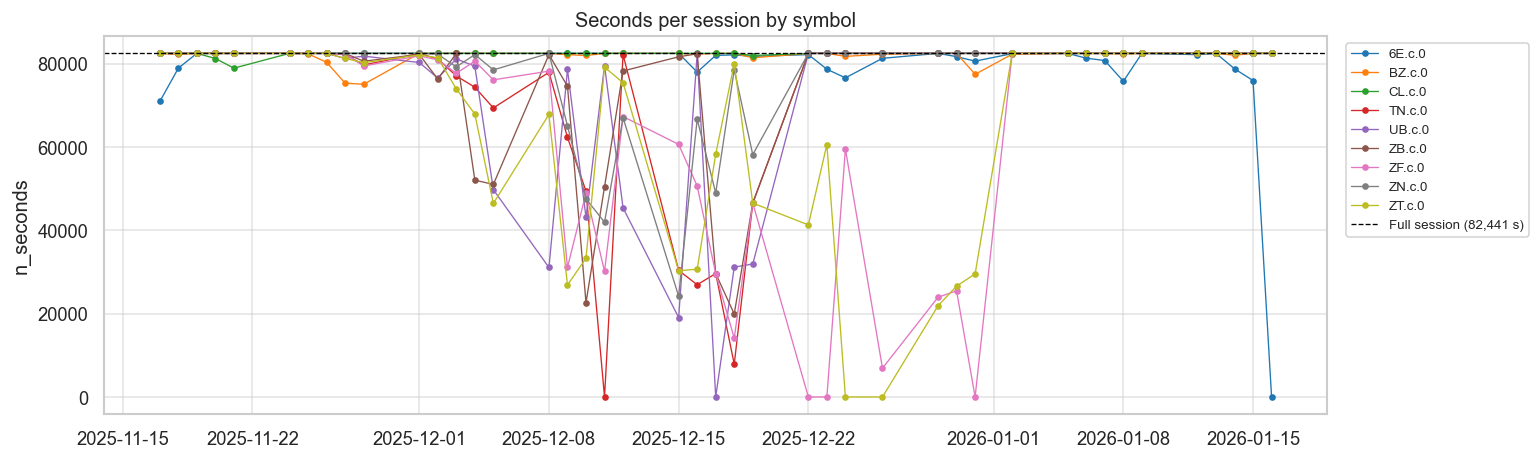

Short sessions (<50% coverage): 34
     symbol session_date  n_seconds
42   6E.c.0   2026-01-16          0
147  TN.c.0   2025-12-11          0
283  ZF.c.0   2025-12-22          0
289  ZF.c.0   2025-12-31          0
372  ZT.c.0   2025-12-26          0
284  ZF.c.0   2025-12-23          0
371  ZT.c.0   2025-12-24          0
194  UB.c.0   2025-12-17          0
286  ZF.c.0   2025-12-26       6901
152  TN.c.0   2025-12-18       7876
281  ZF.c.0   2025-12-18      14090
192  UB.c.0   2025-12-15      19052
238  ZB.c.0   2025-12-18      19904
373  ZT.c.0   2025-12-29      21884
232  ZB.c.0   2025-12-10      22631
287  ZF.c.0   2025-12-29      23931
321  ZN.c.0   2025-12-15      24176
288  ZF.c.0   2025-12-30      25459
374  ZT.c.0   2025-12-30      26609
360  ZT.c.0   2025-12-09      26864
150  TN.c.0   2025-12-16      26935
375  ZT.c.0   2025-12-31      29524
237  ZB.c.0   2025-12-17      29625
151  TN.c.0   2025-12-17      29625
280  ZF.c.0   2025-12-17      29625
276  ZF.c.0   2025-12-11     

In [23]:
FULL_SESSION_SECS = 82800 - 59 - 300  # 82,441

sess_coverage = (
    df.groupby(["symbol", "session_date"])
    .size()
    .rename("n_seconds")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4))
for sym, grp in sess_coverage.groupby("symbol"):
    ax.plot(grp["session_date"], grp["n_seconds"], marker=".", linewidth=0.8, label=sym)
ax.axhline(FULL_SESSION_SECS, color="black", linestyle="--", linewidth=0.8,
           label=f"Full session ({FULL_SESSION_SECS:,} s)")
ax.set_title("Seconds per session by symbol")
ax.set_ylabel("n_seconds")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# sessions with fewer than 50% of expected seconds — likely holidays
short = sess_coverage[sess_coverage["n_seconds"] < FULL_SESSION_SECS * 0.5]
print(f"Short sessions (<50% coverage): {len(short)}")
print(short.sort_values("n_seconds"))

## 6. Distributions — Histograms

Seconds with non-zero log_return: 773,184 (2.7%)


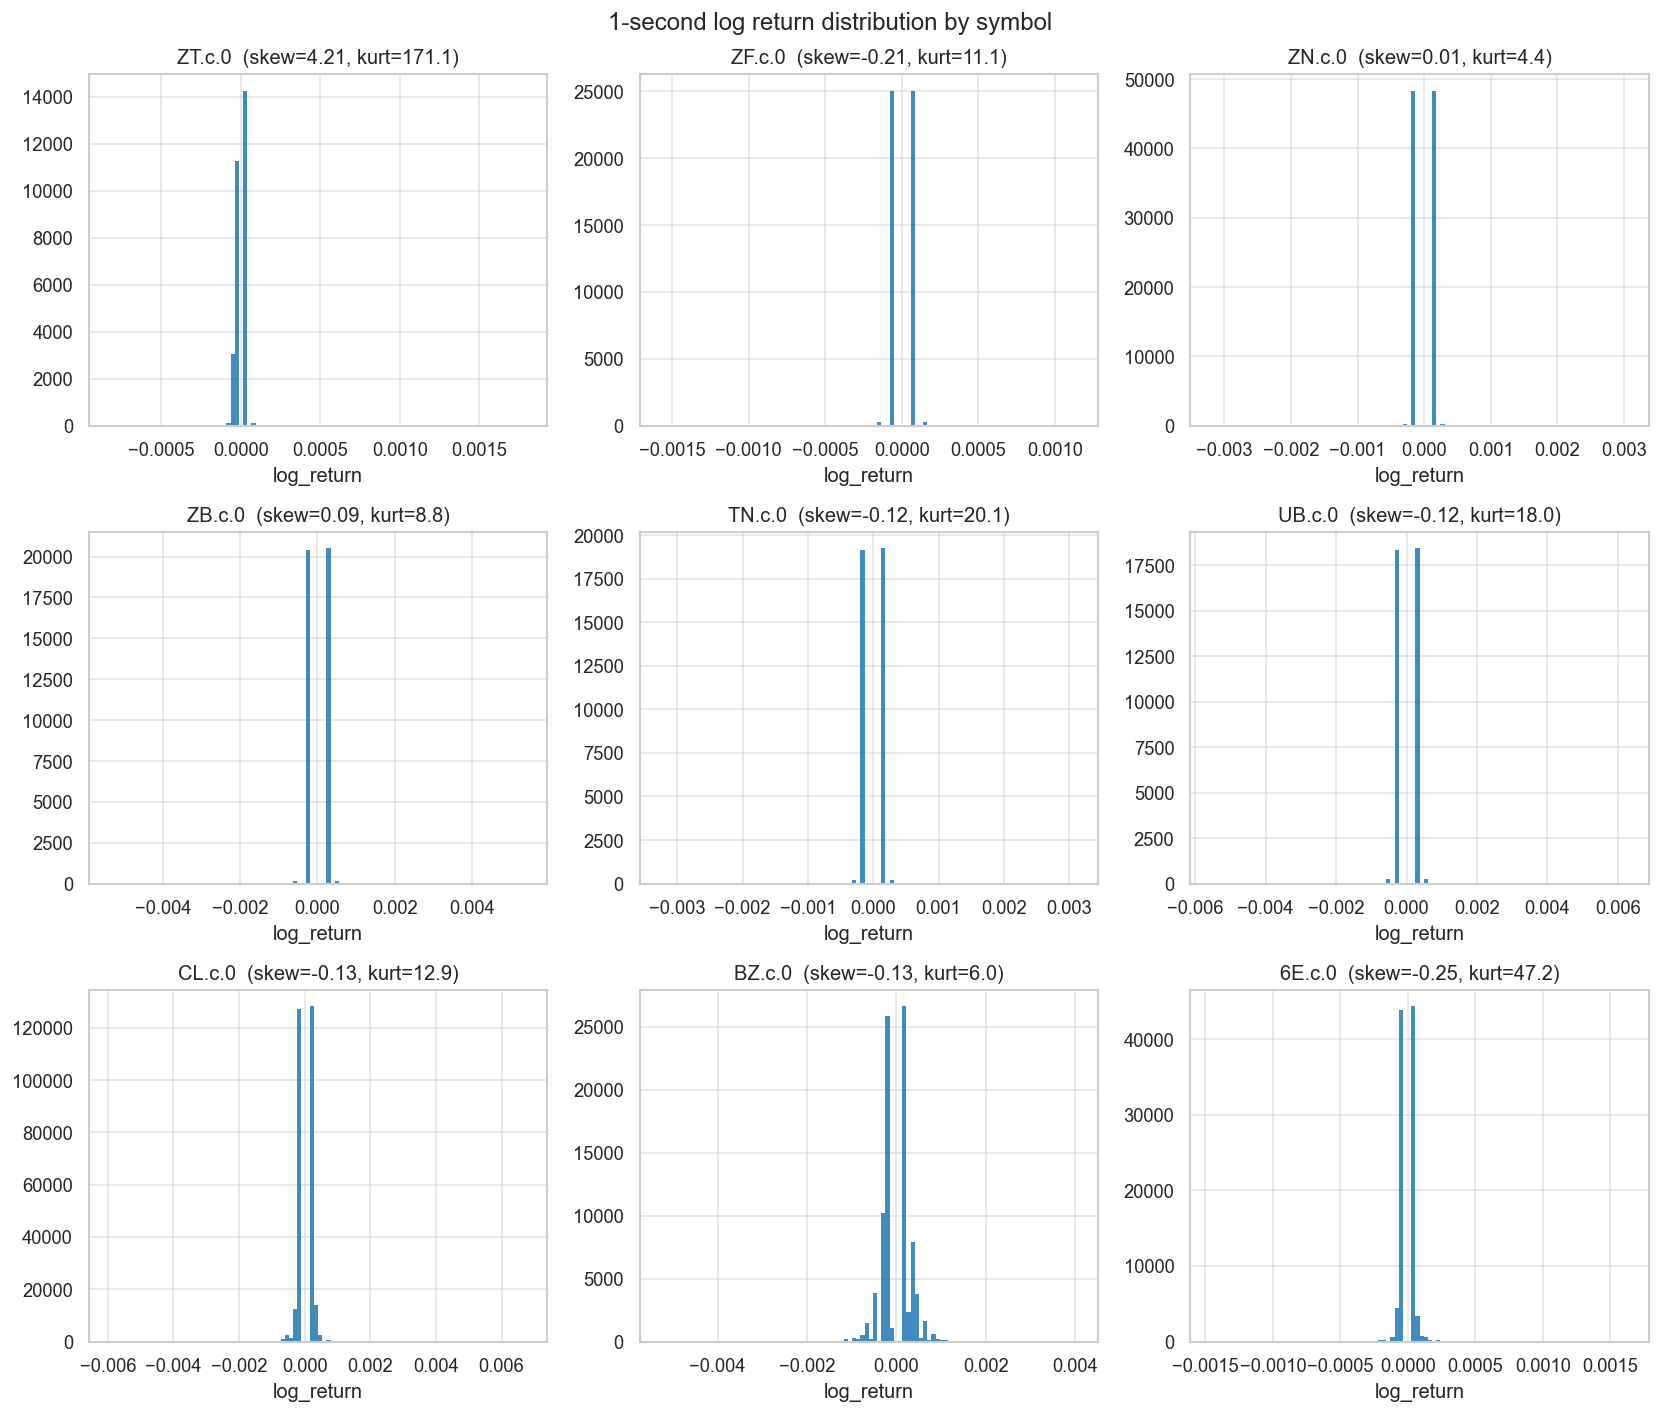

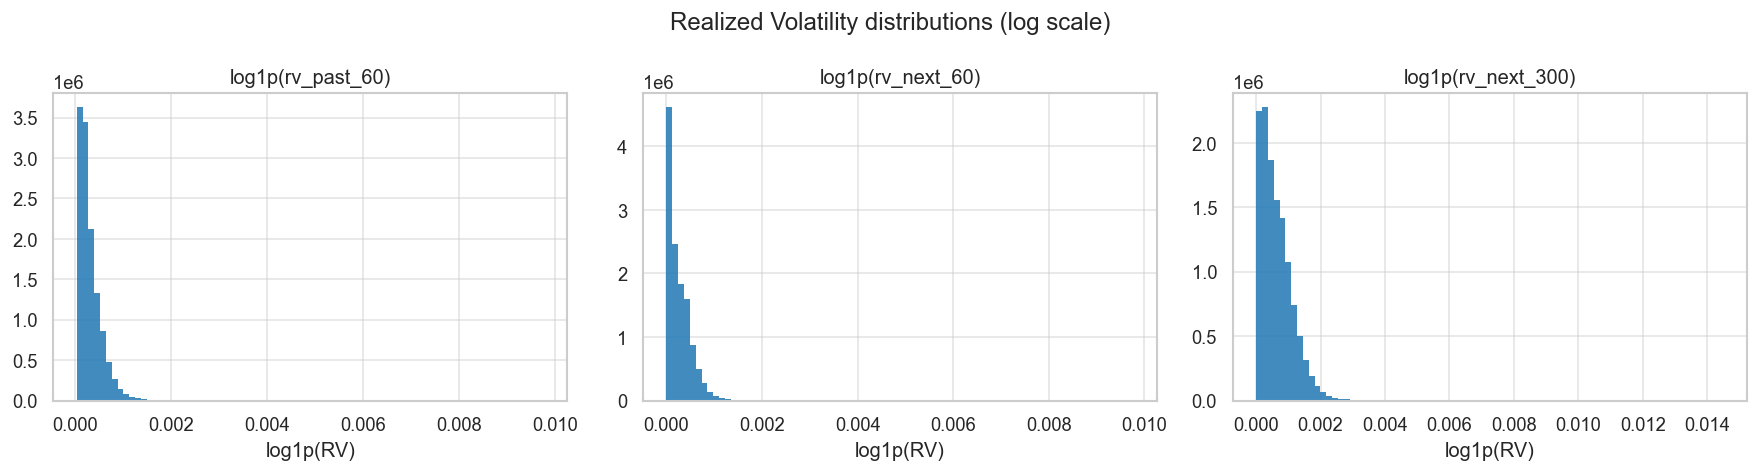

In [24]:
ret_df = df[df["log_return"] != 0]
print(f"Seconds with non-zero log_return: {len(ret_df):,} ({len(ret_df)/len(df)*100:.1f}%)")

n_syms = len(SYMBOLS)
ncols  = 3
nrows  = (n_syms + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))

for ax, sym in zip(axes.flat, SYMBOLS):
    vals = ret_df.loc[ret_df["symbol"] == sym, "log_return"].dropna()
    if vals.empty:
        ax.set_title(f"{sym} (no data)")
        continue
    vals.hist(bins=100, ax=ax, edgecolor="none", alpha=0.85)   # pandas .hist()
    ax.set_title(f"{sym}  (skew={vals.skew():.2f}, kurt={vals.kurtosis():.1f})")
    ax.set_xlabel("log_return")
for ax in axes.flat[n_syms:]:
    ax.set_visible(False)

plt.suptitle("1-second log return distribution by symbol")
plt.tight_layout()
plt.show()

# RV distribution
rv_cols = [c for c in ["rv_past_60", "rv_next_60", "rv_next_300"] if c in df.columns]
rv_df   = df[df["rv_past_60"] > 0]
fig, axes = plt.subplots(1, len(rv_cols), figsize=(5 * len(rv_cols), 4))
if len(rv_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, rv_cols):
    np.log1p(rv_df[col].dropna()).hist(bins=80, ax=ax, edgecolor="none", alpha=0.85)
    ax.set_title(f"log1p({col})")
    ax.set_xlabel("log1p(RV)")
plt.suptitle("Realized Volatility distributions (log scale)")
plt.tight_layout()
plt.show()

## 7. Box Plots — Distributions Across Groups

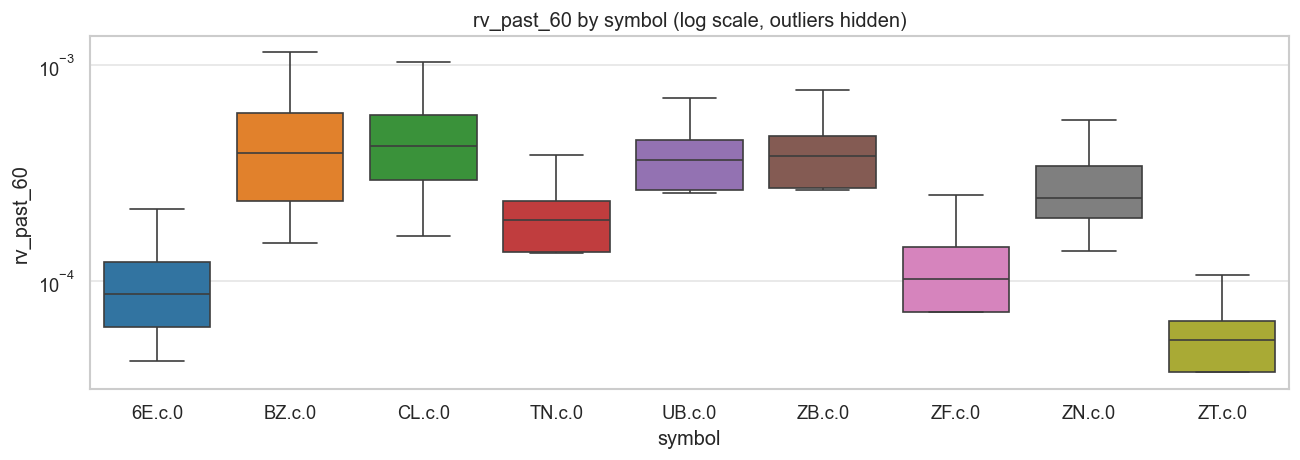

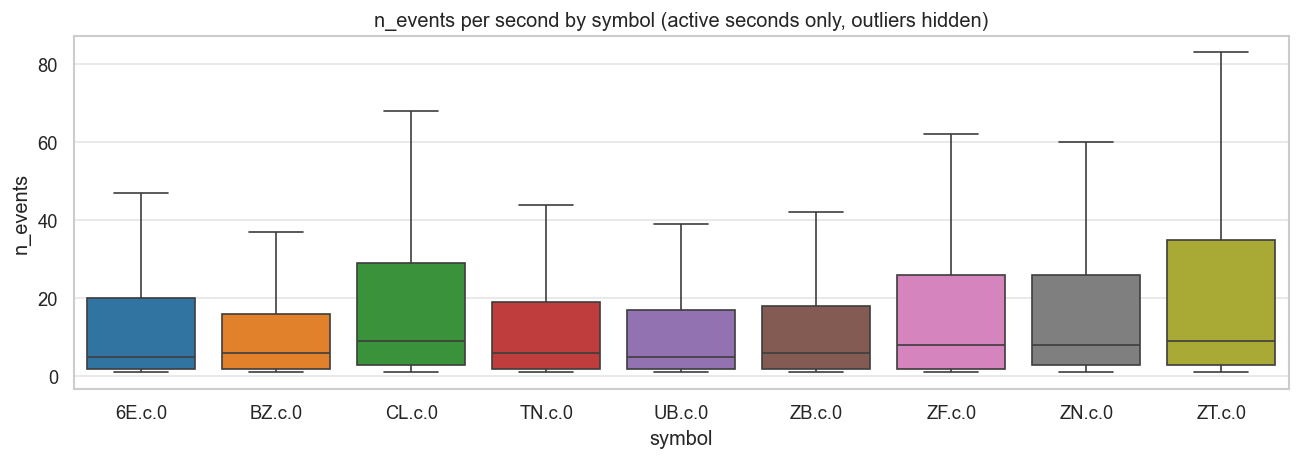

In [25]:
# rv_past_60 by symbol — box plot (non-zero rows, log scale)
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=rv_df, x="symbol", y="rv_past_60", palette="tab10",
            showfliers=False, ax=ax)
ax.set_yscale("log")
ax.set_title("rv_past_60 by symbol (log scale, outliers hidden)")
ax.set_xlabel("symbol")
ax.set_ylabel("rv_past_60")
plt.tight_layout()
plt.show()

# n_events by symbol — box plot (active seconds only)
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df[df["n_events"] > 0], x="symbol", y="n_events", palette="tab10",
            showfliers=False, ax=ax)
ax.set_title("n_events per second by symbol (active seconds only, outliers hidden)")
ax.set_xlabel("symbol")
ax.set_ylabel("n_events")
plt.tight_layout()
plt.show()

## 8. Correlation Matrix

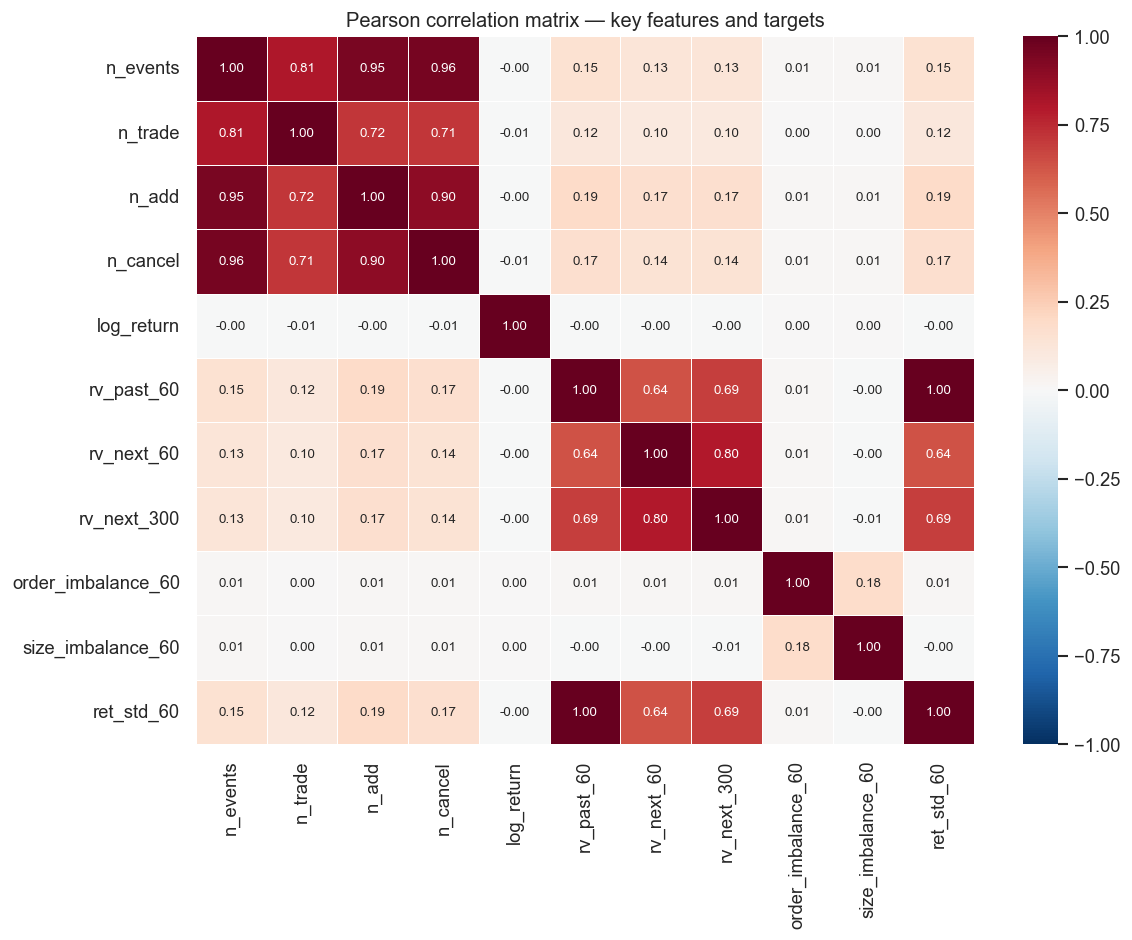

In [26]:
corr_cols = [
    "n_events", "n_trade", "n_add", "n_cancel",
    "log_return", "rv_past_60", "rv_next_60", "rv_next_300",
    "order_imbalance_60", "size_imbalance_60", "ret_std_60",
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Pearson correlation matrix — key features and targets")
plt.tight_layout()
plt.show()

## 9. Grouped Aggregations — Order Flow

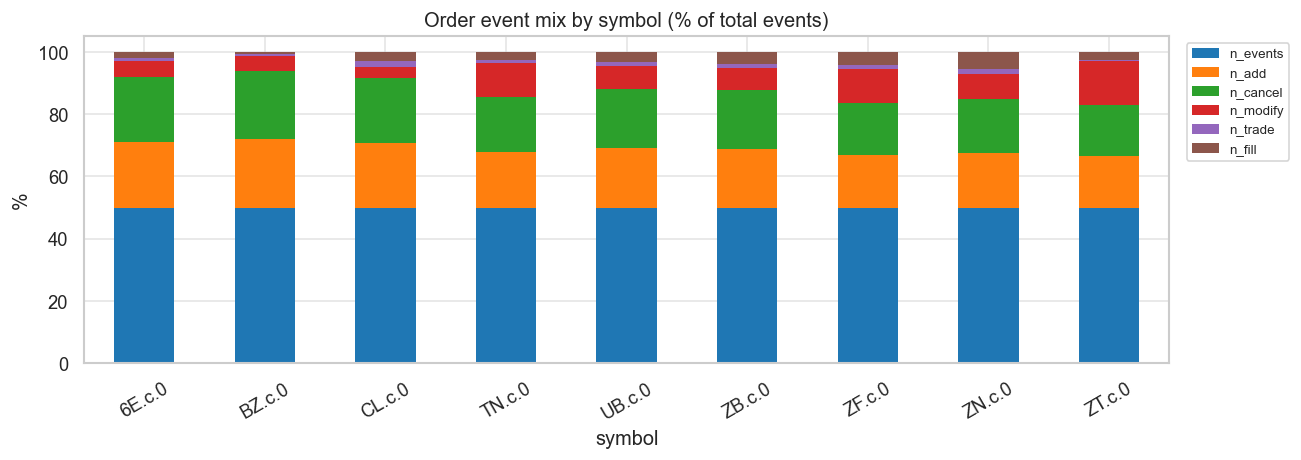

In [27]:
flow_cols = ["n_events", "n_add", "n_cancel", "n_modify", "n_trade", "n_fill"]

# mean and median per symbol
df.groupby("symbol")[flow_cols].agg(["mean", "median"]).round(2)

# event mix — % of total events per type
action_pct = df.groupby("symbol")[flow_cols].sum()
action_pct = action_pct.div(action_pct.sum(axis=1), axis=0) * 100

action_pct.plot(
    kind="bar", stacked=True, figsize=(11, 4),
    edgecolor="none", title="Order event mix by symbol (% of total events)"
)
plt.ylabel("%")
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Time Series — Sample Session

Visual sanity check: price continuity, log return spikes, RV envelope, event activity.

6E.c.0 — 2026-01-15  (75,919 seconds)


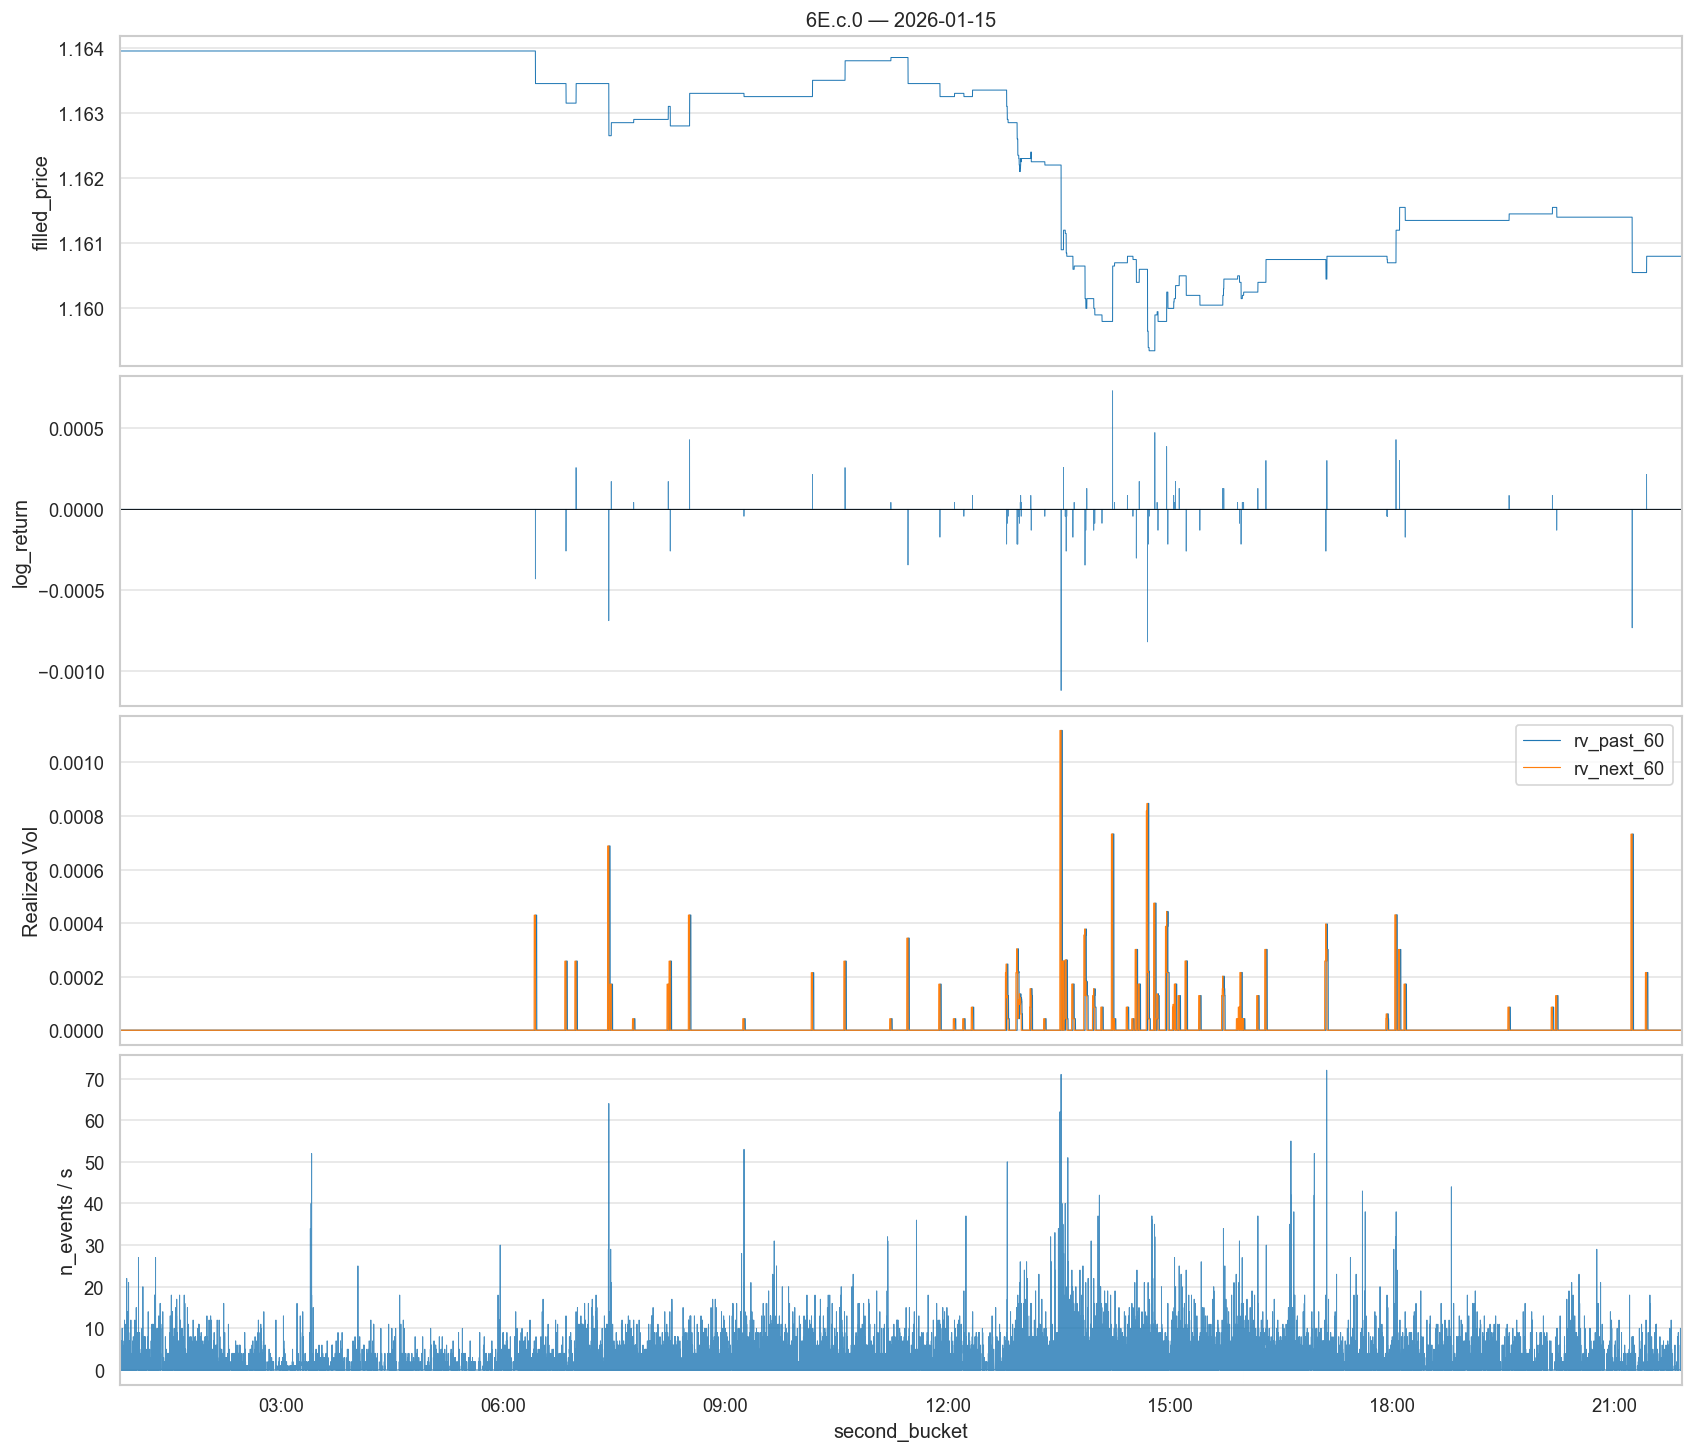

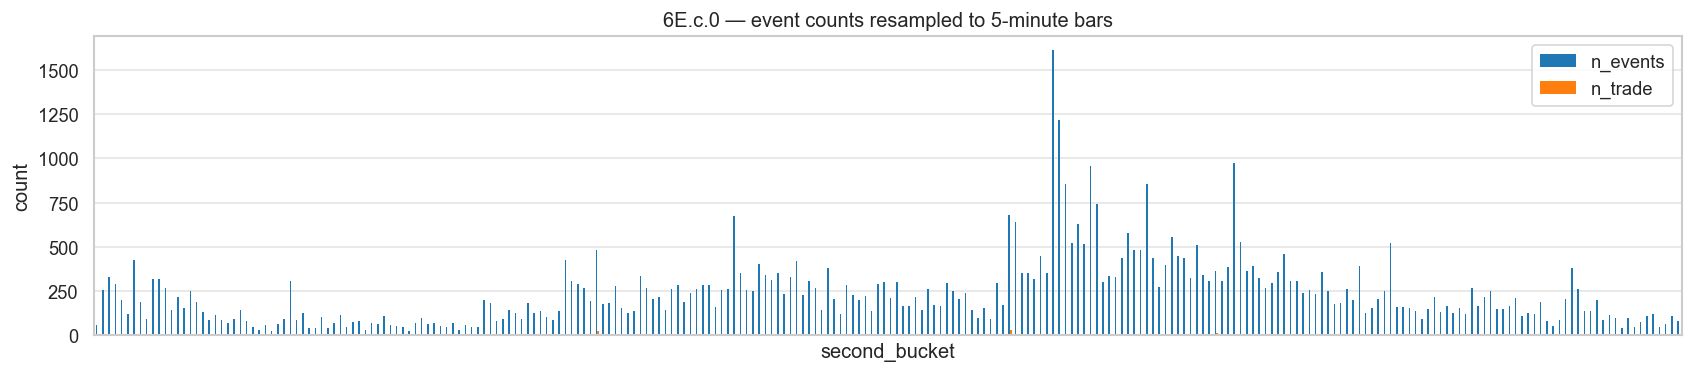

In [28]:
PLOT_SYMBOL = "6E.c.0"   # ← change as desired

latest_session = df[df["symbol"] == PLOT_SYMBOL]["session_date"].max()
sess = (
    df[(df["symbol"] == PLOT_SYMBOL) & (df["session_date"] == latest_session)]
    .sort_values("second_bucket")
    .set_index("second_bucket")
)
print(f"{PLOT_SYMBOL} — {latest_session}  ({len(sess):,} seconds)")

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

sess["filled_price"].plot(ax=axes[0], linewidth=0.6)
axes[0].set_ylabel("filled_price")
axes[0].set_title(f"{PLOT_SYMBOL} — {latest_session}")

sess["log_return"].plot(ax=axes[1], linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("log_return")

sess[["rv_past_60", "rv_next_60"]].plot(ax=axes[2], linewidth=0.7)
axes[2].set_ylabel("Realized Vol")

sess["n_events"].plot(ax=axes[3], linewidth=0.6, alpha=0.8)
axes[3].set_ylabel("n_events / s")

fig.autofmt_xdate(rotation=30)
plt.show()

# resample to 5-minute bars
sess_5m = sess[["n_events", "n_trade", "rv_past_60"]].resample("5min").agg({
    "n_events":   "sum",
    "n_trade":    "sum",
    "rv_past_60": "last",
})
fig2, ax2 = plt.subplots(figsize=(14, 3), constrained_layout=True)
sess_5m[["n_events", "n_trade"]].plot(
    kind="bar", edgecolor="none", ax=ax2,
    title=f"{PLOT_SYMBOL} — event counts resampled to 5-minute bars"
)
ax2.set_ylabel("count")
ax2.set_xticks([])
plt.show()